In [1]:
%reset -f
# %matplotlib widget
import numpy as np
import math
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.widgets import Slider
# import mplcursors
# import plotly.graph_objects as go
from scipy.integrate import cumtrapz
# import plotly.io as pio
from IPython.display import HTML
from scipy.interpolate import interp1d
from scipy.io import loadmat
import datetime
import scipy.io as sio
import os
import itertools
from matplotlib.colors import Normalize
from datetime import datetime, timedelta

# from my_functions import pull_dc

from IPython.display import display, HTML
display(HTML("""
<style>
    .container { width: 100% !important; }
    code, pre { font-size: 16px !important; }
</style>
"""))
plt.rcParams.update({
    "font.size": 10, "font.family": "sans-serif",
    "axes.grid": False, "grid.alpha": 0.3, "grid.linewidth": 0.5,
    "axes.axisbelow": True,
})

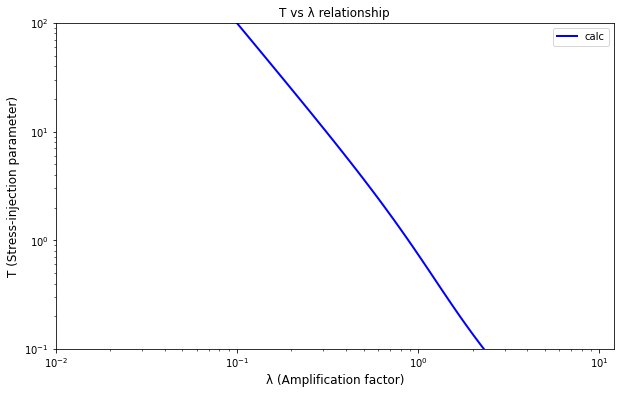

In [2]:
from scipy.special import exp1  # This is E_1, the exponential integral

def g(xi, lam, epsilon):
    term1 = exp1(lam**2 * xi**2)
    term2 = exp1(lam**2)
    term3 = (lam**(-2)) * np.exp(-lam**2)
    return term1 - term2 + term3 - epsilon

#  the integral for T 
def compute_T(lam, epsilon):
    from scipy.integrate import quad
    
    def integrand(xi):
        return g(xi, lam, epsilon) * xi / np.sqrt(1 - xi**2)
    
    result, error = quad(integrand, 0, 1)
    return result

#range of lambda values
lambda_values = np.logspace(-2, 2, 100)  
epsilon = 0  

T_values = []
for lam in lambda_values:
    T_val = compute_T(lam, epsilon)
    T_values.append(T_val)

# Plot
plt.figure(figsize=(10, 6))
plt.loglog(lambda_values, T_values, 'b-', linewidth=2, label='calc')
# plt.loglog(lambda_ref, T_ref, 'r--', linewidth=2, label='Reference')  # Add your reference data
plt.xlabel('λ (Amplification factor)', fontsize=12)
plt.ylabel('T (Stress-injection parameter)', fontsize=12)
plt.ylim([1e-1, 1e2])
plt.xlim([1e-2, 12])
plt.legend()
plt.title('T vs λ relationship')
plt.show()

In [3]:
lam = np.asarray(lambda_values)
T   = np.asarray(T_values)

# inverse map λ(T): sort by T so interp1d is happy
order = np.argsort(T)
T_s   = T[order]
lam_s = lam[order]

lam_of_T = interp1d(np.log(T_s), np.log(lam_s),kind="linear", bounds_error=True)

def lambda_from_T(T_pull):
    T_pull = np.asarray(T_pull)
    return np.exp(lam_of_T(np.log(T_pull)))


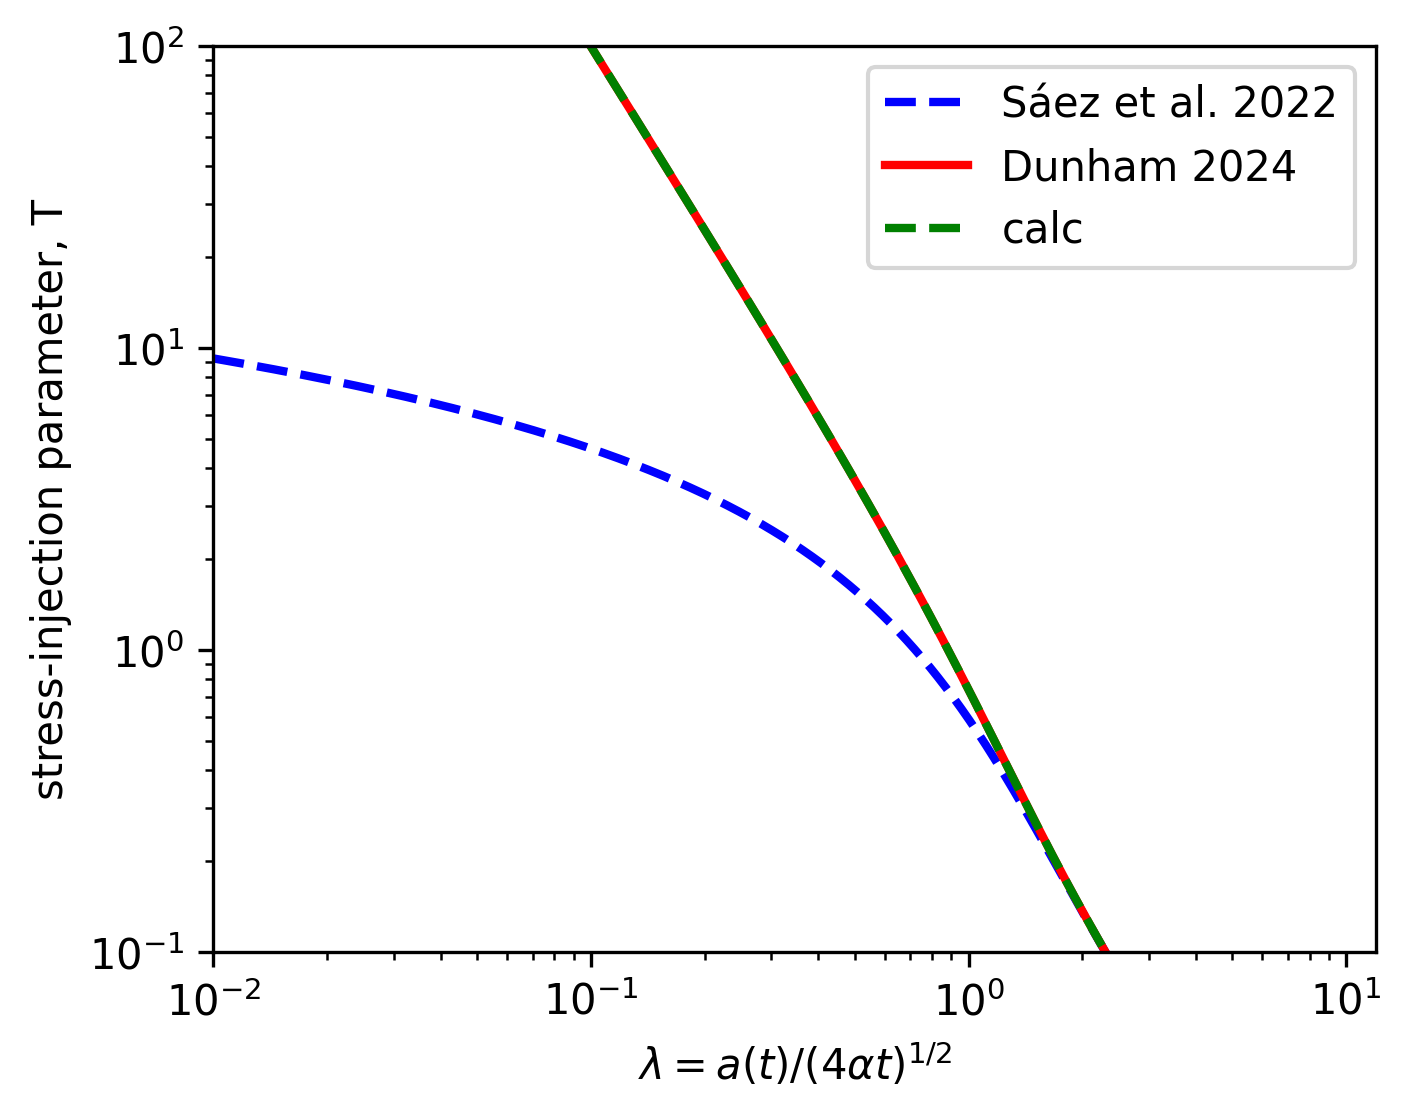

In [4]:
df = pd.read_csv('../../hbi/Tlambda3D.csv')
plt.figure(figsize=(5,4),dpi = 300)
# plt.loglog(df['lambda'], df['T3_SL'],'b--', linewidth=2, label='SLBV22')
plt.loglog(df['lambda'], df['T3_SL'],'b--', linewidth=2, label='Sáez et al. 2022')

# plt.loglog(df['lambda'], df['T3'], 'r',linewidth=2, label='D24')
plt.loglog(df['lambda'], df['T3'], 'r',linewidth=2, label='Dunham 2024')

plt.loglog(lambda_values, T_values, 'g--', linewidth=2, label='calc')


plt.xlabel(r'$\lambda = a(t)/(4\alpha t)^{1/2}$', fontsize = 10)
plt.ylabel('stress-injection parameter, T', fontsize = 10)
plt.ylim([1e-1, 1e2])
plt.xlim([1e-2, 12])
plt.legend()
# plt.title('3D constant rate injection')
# plt.tight_layout()
plt.show()


In [5]:
pwd

'/home/users/nberrios/3dhbi/hbi_analysis/notebooks'

T_final = 9.583333333333334
lambda = 0.31695523161322137
origin derivative approx: -2.0  (target -2.0 )


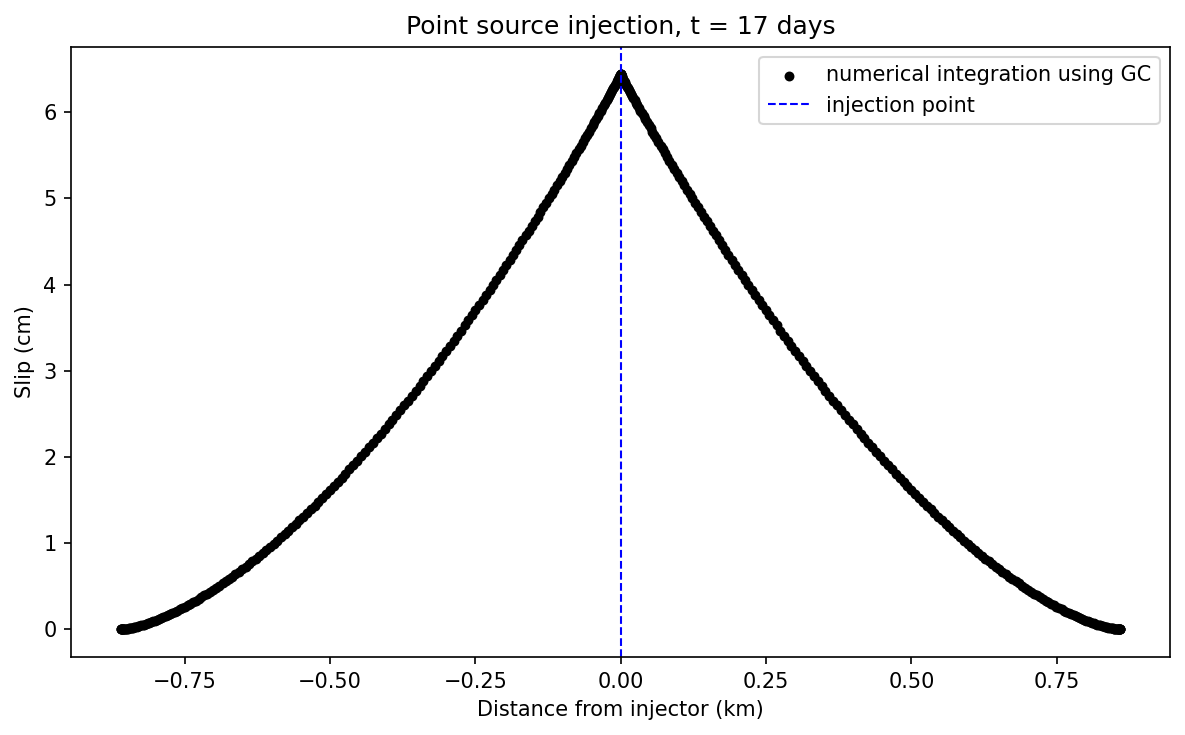

saved linear solution
lambda linear: 0.31695523161322137
max slip (cm): 6.4408508353326175


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk as K
from scipy.special import ellipe as E

# assumes lambda_from_T() and g() are already defined

# physical parameters
f = 0.6
sigma_0 = 30e6
tau_0   = 11.1e6
deltaP  = 1.2e6
alpha = 1.25
mu = 24e9
deltaTau = 5e6
gamma_const = deltaTau / mu

# time
some_time_days = 17
some_time_sec = some_time_days * 24 * 3600

# a lot of the code is the same, so setting up two different cases
case = "point"  # options: "constant" or "point"

# GC setup
# NOTE: n = 10000 does not work. The dense matrices are ~800 MB each (several
# are built), and the elliptic parameter m below rounds to exactly 1.0 near the
# crack edge, which makes K(m) = inf. Start at 200 and raise it for the
# resolution study.
n = 200

a_idx = np.arange(1, n)
b_idx = np.arange(1, n + 1)

# Mapped coordinates in [-1, 1]
rtilde_i = np.cos(np.pi * a_idx / n)              # collocation points, shape (n-1,)
stilde_j = np.cos(np.pi * (b_idx - 0.5) / n)      # quadrature points, shape (n,)

# Unmapped radial coordinates in [0, 1]
rbar_i = 0.5 * (rtilde_i + 1.0)                   # collocation points
sbar_j = 0.5 * (stilde_j + 1.0)                   # quadrature points

# Build kernel matrix in mapped coordinates
# This ratio is rbar_i / sbar_j, written using mapped variables:
# rbar_i / sbar_j = (rtilde_i + 1) / (stilde_j + 1)

rbar_over_sbar = (rtilde_i[:, None] + 1.0) / (stilde_j[None, :] + 1.0)

# scipy's ellipk/ellipe take the parameter m = k^2, so form m directly instead
# of computing k and squaring it: the sqrt-then-square round trip can return a
# value slightly greater than 1, where both functions return nan.
m_parameter = 4.0 * rbar_over_sbar / (1.0 + rbar_over_sbar)**2

# m -> 1 as adjacent nodes approach each other, and at large n it reaches 1.0
# in double precision, where K(1) = inf. Clamp just below. This is harmless:
# K diverges only logarithmically, so K(1 - 1e-16) is about 19.9, which is the
# correct magnitude at any resolution reachable here.
m_parameter = np.minimum(m_parameter, np.nextafter(1.0, 0.0))

elliptic_K = K(m_parameter)
elliptic_E = E(m_parameter)

kernel_matrix = (elliptic_K / (stilde_j[None, :] + rtilde_i[:, None] + 2.0)
                 + elliptic_E / (stilde_j[None, :] - rtilde_i[:, None]))
A_matrix = (-1.0 / n) * kernel_matrix


# RHS and center condition
if case == "constant":
    # Constant stress-drop loading
    gamma_i = gamma_const * np.ones(n - 1)
    # Mapped center gradient q0 = 0
    center_gradient_target = 0.0
    # Physical crack radius for dimensional plotting
    R_t = 50
    # For constant stress drop, delta_physical = R_t * delta_tilde
    dim_factor = R_t
    lam = None
    plot_title = "Constant stress drop"

elif case == "point":
    T_final = (f * sigma_0 - tau_0) / (f * deltaP)
    print("T_final =", T_final)
    lam = lambda_from_T(T_final)
    print("lambda =", lam)
    # Point-source loading evaluated in bar coordinates
    gamma_i = g(rbar_i, lam, 0.0) - T_final
    # Mapped center gradient q0 = -2
    center_gradient_target = -2.0
    # Physical crack radius
    R_t = lam * np.sqrt(4.0 * alpha * some_time_sec)
    # delta_physical = R_t * (f deltaP / mu) * delta_tilde
    dim_factor = R_t * f * deltaP / mu
    plot_title = f"Point source injection, t = {some_time_days} days"


### origin asymptotic condition
# origin is stilde = -1.
# Since stilde_j is ordered from +1 to -1, stilde_j[-1] is closest to -1.
j_center = -1
origin_row = np.zeros((1, n))
origin_row[0, j_center] = 1.0 / np.sqrt(1.0 - stilde_j[j_center]**2)
origin_rhs = center_gradient_target

# Full linear system for phi_j
A_full = np.vstack([A_matrix, origin_row])
rhs_full = np.concatenate([gamma_i, [origin_rhs]])

# solve() returns all-nan without raising if anything upstream is inf or nan,
# and the only symptom downstream is an empty plot, so check here instead.
assert np.isfinite(A_full).all(), "non-finite entries in the kernel matrix"
assert np.isfinite(rhs_full).all(), "non-finite entries in the right hand side"

phi_j = np.linalg.solve(A_full, rhs_full)
assert np.isfinite(phi_j).all(), "solve returned non-finite phi"

## check how the center derivative compares to what you expect from asymptotics
center_derivative_approx = phi_j[j_center] / np.sqrt(1.0 - stilde_j[j_center]**2)
print("origin derivative approx:", center_derivative_approx,
      " (target", center_gradient_target, ")")

# Reconstruct nondimensional slip from edge inward
# delta_tilde(stilde_k) = -(pi/n) sum_j phi_j H(stilde_j - stilde_k)
# stilde_j is ordered from +1 down to -1, so H(stilde_j - stilde_k) = 1 exactly
# when j < k. The double sum is therefore a cumulative sum, which is O(n)
# instead of O(n^2) and gives bit-identical results.
delta_tilde = -(np.pi / n) * np.concatenate([[0.0], np.cumsum(phi_j)[:-1]])

### Dimensionalize
# physical radius is r = sbar * R_t
r_physical = sbar_j * R_t
slip_physical = dim_factor * delta_tilde

# Mirror to full diameter for plotting, keeping the radius monotonic
r_full = np.concatenate([-r_physical, r_physical[::-1]])
slip_full = np.concatenate([slip_physical, slip_physical[::-1]])


# Eshelby comparison for constant case
if case == "constant":
    nu = 0
    eta = np.pi * (2.0 - nu) / (4.0 * (1.0 - nu))
    crack_radius = R_t
    r_abs = np.abs(r_full)
    slip_eshelby = ((2.0 * crack_radius * deltaTau) / (mu * eta)
                    * np.sqrt(np.clip(1.0 - (r_abs / crack_radius)**2, 0.0, None)))

    print("max |numerical - Eshelby| (cm):",
        np.nanmax(np.abs(slip_full - slip_eshelby)) * 100)

### plot
plt.figure(figsize=(8, 5), dpi=150)
plt.scatter(r_full / 1000.0, slip_full * 100.0, s=14, facecolors='k',
            label='numerical integration using GC')

if case == "constant":
    plt.scatter(r_full / 1000, slip_eshelby * 100, s=5, facecolors='none',
                edgecolors='r', label='analytical Eshelby solution')

plt.axvline(0, color='b', linestyle='--', linewidth=1, label='injection point')
plt.xlabel('Distance from injector (km)')
plt.ylabel('Slip (cm)')
plt.title(plot_title)
plt.legend()
plt.tight_layout()
plt.show()

# saving linear result before running nonlinear code
lam_linear = lam
phi_linear = phi_j.copy()
r_full_linear = r_full.copy()
slip_full_linear = slip_full.copy()
R_t_linear = R_t

print("saved linear solution")
print("lambda linear:", lam_linear)
print("max slip (cm):", np.nanmax(slip_full) * 100)

In [15]:
import numpy as np
from scipy.special import ellipk as K
from scipy.special import ellipe as E

# assumes lambda_from_T(), g(), and the physical parameters are already defined:
#   f, sigma_0, tau_0, deltaP, alpha, mu, deltaTau, some_time_sec

T_final = (f * sigma_0 - tau_0) / (f * deltaP)
lam = lambda_from_T(T_final)          # independent of n, so not part of the sweep


def solve_at(n, case="point", origin="1node"):
    """Solve at resolution n. Returns (sbar_j, delta_tilde, rel_interior_residual)."""
    rtilde_i = np.cos(np.pi * np.arange(1, n) / n)
    stilde_j = np.cos(np.pi * (np.arange(1, n + 1) - 0.5) / n)

    u = (rtilde_i[:, None] + 1.0) / (stilde_j[None, :] + 1.0)
    m = np.minimum(4.0 * u / (1.0 + u)**2, np.nextafter(1.0, 0.0))
    kernel = (K(m) / (stilde_j[None, :] + rtilde_i[:, None] + 2.0)
              + E(m) / (stilde_j[None, :] - rtilde_i[:, None]))
    A = (-1.0 / n) * kernel

    if case == "point":
        gamma_i = g(0.5 * (rtilde_i + 1.0), lam, 0.0) - T_final
        q0 = -2.0
    else:
        gamma_i = (deltaTau / mu) * np.ones(n - 1)
        q0 = 0.0

    row = np.zeros(n)
    if origin == "1node":
        row[-1] = 1.0 / np.sqrt(1.0 - stilde_j[-1]**2)
    else:                                     # two-node linear extrapolation to stilde = -1
        w = (-1.0 - stilde_j[-1]) / (stilde_j[-1] - stilde_j[-2])
        row[-1] = (1.0 + w) / np.sqrt(1.0 - stilde_j[-1]**2)
        row[-2] = -w / np.sqrt(1.0 - stilde_j[-2]**2)

    A_full = np.vstack([A, row])
    rhs = np.concatenate([gamma_i, [q0]])
    assert np.isfinite(A_full).all() and np.isfinite(rhs).all()
    phi = np.linalg.solve(A_full, rhs)

    delta_tilde = -(np.pi / n) * np.concatenate([[0.0], np.cumsum(phi)[:-1]])
    resid = np.abs(A @ phi - gamma_i).max() / np.abs(gamma_i).max()
    return 0.5 * (stilde_j + 1.0), delta_tilde, resid


ns = [100, 200, 400, 800, 1600]

# ---- 1. main sweep: does max slip converge, and at what rate? ----------------
R_t = lam * np.sqrt(4.0 * alpha * some_time_sec)
dim_factor = R_t * f * deltaP / mu

dmax, store = {}, {}
print(f"{'n':>6} {'max slip (cm)':>16} {'diff':>12} {'p':>7} {'int resid':>11}")
prev_d = None
for n in ns:
    sbar, dt, resid = solve_at(n)
    store[n] = (sbar, dim_factor * dt * 100.0)
    dmax[n] = dim_factor * dt.max() * 100.0
    line = f"{n:>6} {dmax[n]:>16.8f}"
    if prev_d is not None:
        d = abs(dmax[n] - prev_d)
        line += f" {d:>12.3e}"
        if 'd_old' in dir() and d_old is not None:
            line += f" {np.log2(d_old / d):>7.3f}"
        else:
            line += f" {'':>7}"
        d_old = d
    else:
        d_old = None
        line += f" {'':>12} {'':>7}"
    print(line + f" {resid:>11.2e}")
    prev_d = dmax[n]

# Richardson extrapolation, assuming first order (check p above first)
a, b = dmax[ns[-2]], dmax[ns[-1]]
print(f"\nRichardson (p=1) limit: {2*b - a:.8f} cm")
print(f"error at n=200:         {abs(dmax[200] - (2*b - a)):.3e} cm "
      f"({100*abs(dmax[200] - (2*b - a))/(2*b - a):.3f} %)")

# ---- 2. profile convergence, not just the peak -------------------------------
grid = np.linspace(0.02, 0.98, 400)
sb_f, sl_f = store[ns[-1]]
ref = np.interp(grid, sb_f[::-1], sl_f[::-1])
print("\nprofile vs finest grid:")
for n in ns[:-1]:
    sb, sl = store[n]
    cur = np.interp(grid, sb[::-1], sl[::-1])
    print(f"  n={n:>5}  rel L2 = {np.linalg.norm(cur-ref)/np.linalg.norm(ref):.3e}"
          f"   max abs = {np.abs(cur-ref).max():.3e} cm")

# ---- 3. control A: constant stress drop against the exact Eshelby profile ----
print("\ncontrol: constant stress drop vs Eshelby")
R_c = 50.0
prev_e = None
for n in ns:
    sbar, dt, _ = solve_at(n, case="constant")
    slip = R_c * dt * 100.0
    esh = (2.0 * R_c * deltaTau) / (mu * (np.pi/2)) * np.sqrt(np.clip(1 - sbar**2, 0, None)) * 100.0
    e = np.abs(slip - esh).max()
    print(f"  n={n:>5}  max err = {e:.3e} cm" + (f"   ratio = {prev_e/e:.2f}" if prev_e else ""))
    prev_e = e

# ---- 4. control B: is the origin row the bottleneck? ------------------------
print("\norigin condition: single-node vs two-node row")
for n in ns:
    _, dt1, _ = solve_at(n, "point", "1node")
    _, dt2, _ = solve_at(n, "point", "2node")
    d1, d2 = dim_factor*dt1.max()*100, dim_factor*dt2.max()*100
    print(f"  n={n:>5}  1-node {d1:.8f}   2-node {d2:.8f}   diff {abs(d1-d2):.3e} cm")

     n    max slip (cm)         diff       p   int resid
   100       6.45918226                         3.34e-16
   200       6.44085084    1.833e-02            3.80e-16
   400       6.43123896    9.612e-03   0.931    6.62e-16
   800       6.42632520    4.914e-03   0.968    6.59e-16
  1600       6.42384228    2.483e-03   0.985    1.05e-15

Richardson (p=1) limit: 6.42135937 cm
error at n=200:         1.949e-02 cm (0.304 %)

profile vs finest grid:
  n=  100  rel L2 = 8.911e-03   max abs = 3.801e-02 cm
  n=  200  rel L2 = 4.164e-03   max abs = 1.773e-02 cm
  n=  400  rel L2 = 1.786e-03   max abs = 7.595e-03 cm
  n=  800  rel L2 = 5.954e-04   max abs = 2.531e-03 cm

control: constant stress drop vs Eshelby
  n=  100  max err = 1.473e-02 cm
  n=  200  max err = 7.366e-03 cm   ratio = 2.00
  n=  400  max err = 3.683e-03 cm   ratio = 2.00
  n=  800  max err = 1.841e-03 cm   ratio = 2.00
  n= 1600  max err = 9.207e-04 cm   ratio = 2.00

origin condition: single-node vs two-node row
  n=  10

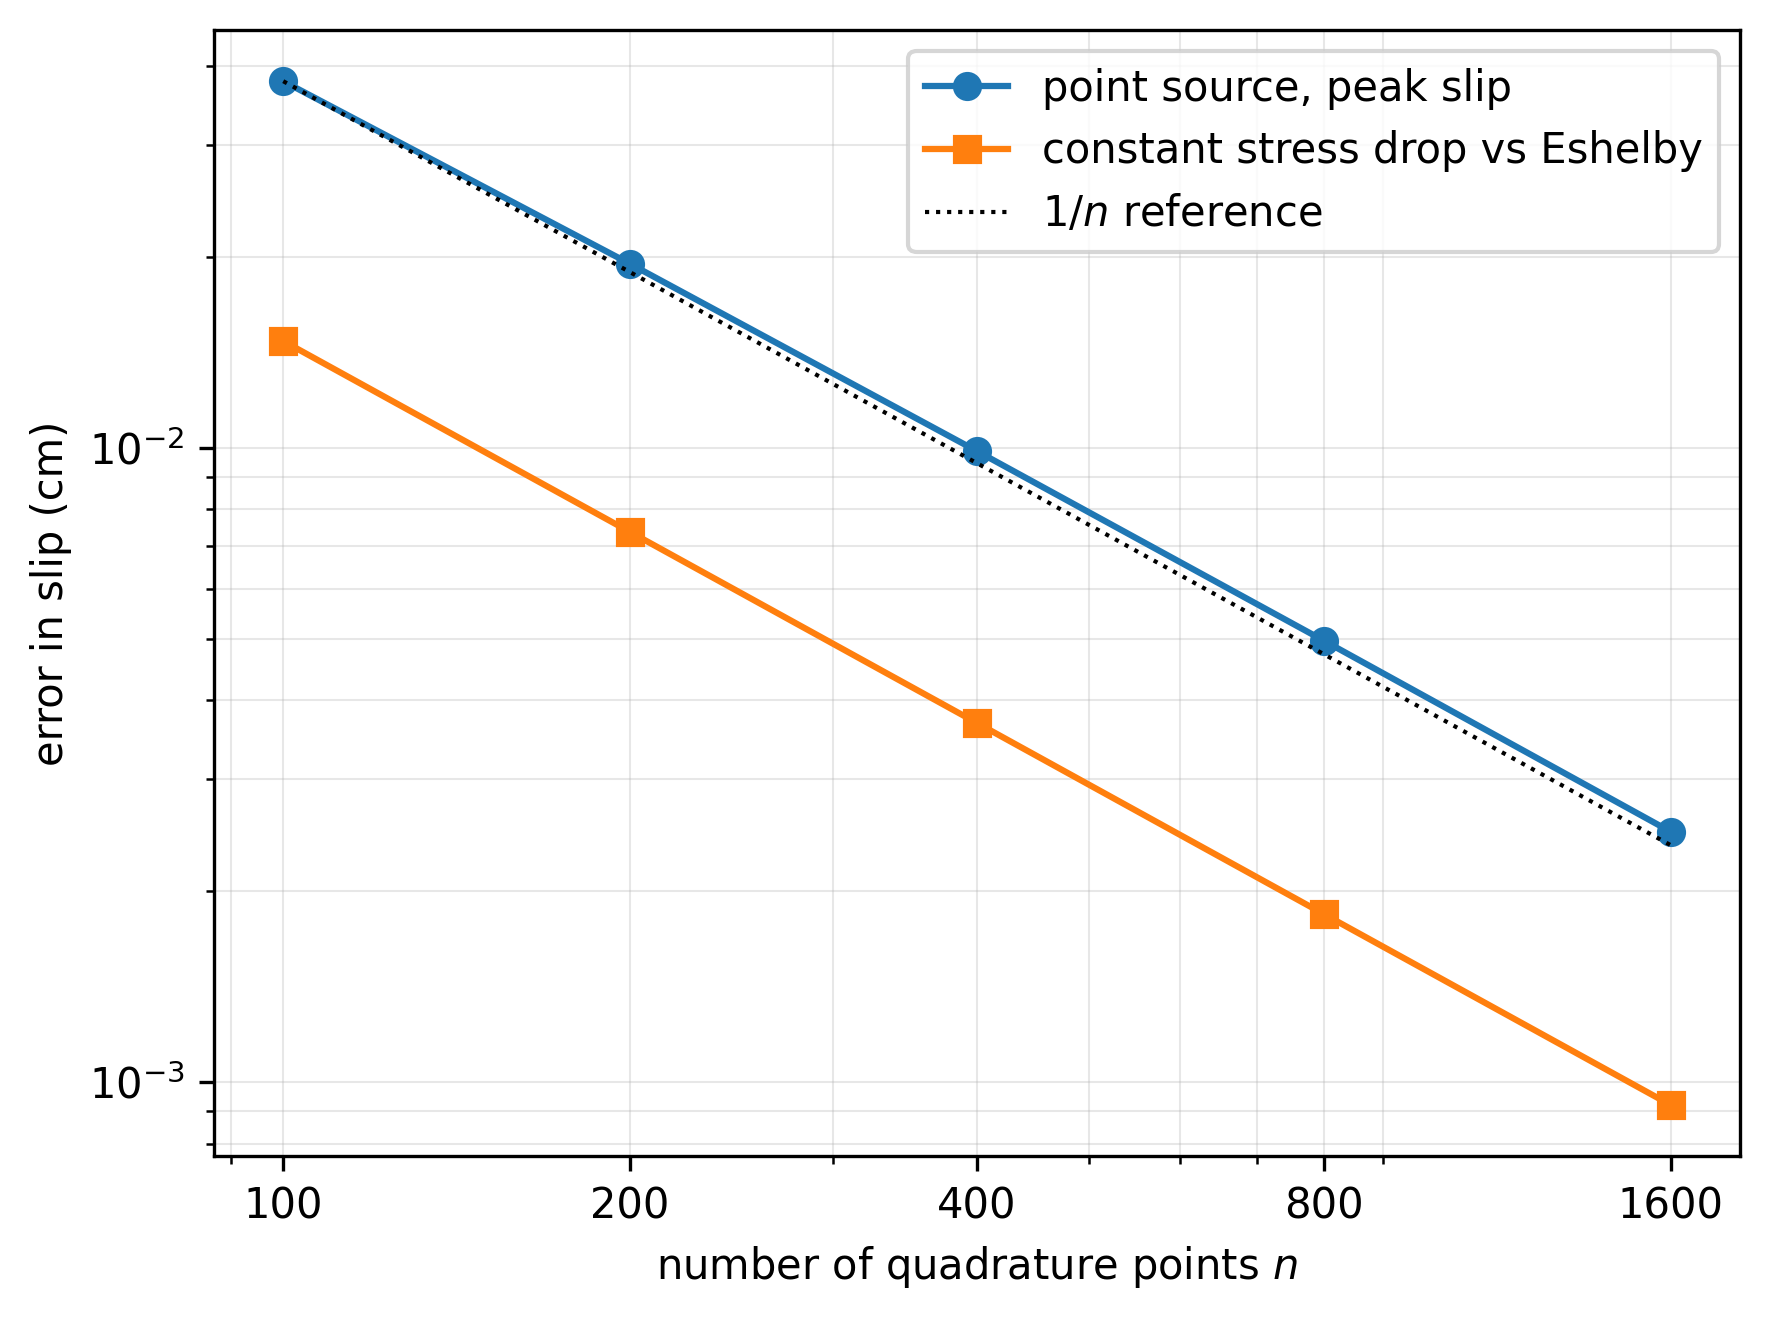

In [16]:
import numpy as np
import matplotlib.pyplot as plt

n        = np.array([100, 200, 400, 800, 1600], dtype=float)
slip_max = np.array([6.45918226, 6.44085084, 6.43123896, 6.42632520, 6.42384228])
eshelby  = np.array([1.473e-2, 7.366e-3, 3.683e-3, 1.841e-3, 9.207e-4])

slip_inf = 2*slip_max[-1] - slip_max[-2]      # Richardson limit, p = 1
err      = np.abs(slip_max - slip_inf)

plt.figure(figsize=(6, 4.5), dpi=300)
plt.loglog(n, err,     'o-', label='point source, peak slip')
plt.loglog(n, eshelby, 's-', label='constant stress drop vs Eshelby')
plt.loglog(n, err[0]*(n/n[0])**-1.0, 'k:', lw=1, label=r'$1/n$ reference')

plt.xlabel('number of quadrature points $n$')
plt.ylabel('error in slip (cm)')
# plt.title(f'first-order convergence, limit {slip_inf:.4f} cm')
plt.xticks(n, [int(v) for v in n])
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('convergence.pdf')
plt.show()

In [17]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---- numbers from the resolution study -------------------------------------
# n = np.array([100, 200, 400, 800, 1600], dtype=float)

# # point-source peak slip, and the p=1 Richardson limit from the two finest grids
# slip_max = np.array([6.45918226, 6.44085084, 6.43123896, 6.42632520, 6.42384228])
# slip_inf = 2*slip_max[-1] - slip_max[-2]          # 6.42135937 cm
# err_peak = np.abs(slip_max - slip_inf)

# # constant stress drop: max |numerical - Eshelby|, an error against an exact solution
# err_eshelby = np.array([1.473e-2, 7.366e-3, 3.683e-3, 1.841e-3, 9.207e-4])

# # origin condition: single-node row vs two-node extrapolated row, same n
# err_origin = np.array([1.878e-6, 4.708e-7, 1.178e-7, 2.945e-8, 7.364e-9])

# # fitted rates on the three finest grids
# def rate(e):
#     return -np.polyfit(np.log(n[-3:]), np.log(e[-3:]), 1)[0]

# plt.rcParams.update({
#     "font.size": 10, "font.family": "serif",
#     "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.5,
#     "axes.axisbelow": True,
# })
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# # ---- panel (a): error vs n, log-log ----------------------------------------
# ax1.loglog(n, err_peak, 'o-', color='#1f3d7a', ms=5, lw=1.4,
#            label=f'point source, peak slip  ($p={rate(err_peak):.2f}$)')
# ax1.loglog(n, err_eshelby, 's-', color='#b03030', ms=5, lw=1.4,
#            label=f'constant stress drop vs Eshelby  ($p={rate(err_eshelby):.2f}$)')
# ax1.loglog(n, err_origin, '^-', color='#2e7d4f', ms=5, lw=1.4,
#            label=f'origin row, 1-node vs 2-node  ($p={rate(err_origin):.2f}$)')

# # slope triangles in the empty band between the curves
# def slope_triangle(ax, x0, x1, y0, p, label):
#     y1 = y0 * (x1/x0)**(-p)
#     ax.plot([x0, x1], [y0, y0], '-', color='0.35', lw=1.0)
#     ax.plot([x1, x1], [y0, y1], '-', color='0.35', lw=1.0)
#     ax.plot([x0, x1], [y0, y1], '-', color='0.35', lw=1.0)
#     ax.text(np.sqrt(x0*x1), y0*1.5, '1', color='0.35', fontsize=8.5, ha='center')
#     ax.text(x1*1.12, np.sqrt(y0*y1), label, color='0.35', fontsize=8.5, va='center')

# slope_triangle(ax1, 220, 440, 3.0e-4, 1.0, '1')
# slope_triangle(ax1, 220, 440, 1.2e-5, 2.0, '2')

# ax1.set_ylim(2e-9, 3e-1)

# ax1.set_xlabel(r'number of quadrature points $n$')
# ax1.set_ylabel(r'error in slip (cm)')
# ax1.set_title('(a) convergence of the discretization', fontsize=10, loc='left')
# ax1.set_xticks(n)
# ax1.set_xticklabels([f'{int(v)}' for v in n])
# ax1.legend(fontsize=8.5, loc='upper right', framealpha=0.95)

# # ---- panel (b): peak slip against 1/n, linear ------------------------------
# inv = 1.0/n
# ax2.plot(inv*1e3, slip_max, 'o', color='#1f3d7a', ms=6, zorder=3,
#          label='computed peak slip')

# # straight line through the two finest points, extended to 1/n = 0
# fit = np.polyfit(inv[-2:], slip_max[-2:], 1)
# xs = np.linspace(0, inv[0]*1.05, 100)
# ax2.plot(xs*1e3, np.polyval(fit, xs), '-', color='#1f3d7a', lw=1.2, alpha=0.7,
#          label='first-order fit (two finest)')
# ax2.plot(0, slip_inf, '*', color='#b03030', ms=14, zorder=4,
#          label=f'extrapolated limit, {slip_inf:.4f} cm')
# ax2.axhline(slip_inf, color='#b03030', ls=':', lw=1.0)

# for ni, si in zip(n, slip_max):
#     ax2.annotate(f'{int(ni)}', xy=(1e3/ni, si), xytext=(4, 4),
#                  textcoords='offset points', fontsize=8, color='0.4')

# ax2.set_xlabel(r'$10^{3}/n$')
# ax2.set_ylabel('peak slip (cm)')
# ax2.set_title('(b) extrapolation of the peak slip', fontsize=10, loc='left')
# ax2.set_xlim(left=-0.4)
# ax2.legend(fontsize=8.5, loc='lower right', framealpha=0.95)

# fig.tight_layout()
# fig.savefig('convergence.pdf', bbox_inches='tight')
# fig.savefig('convergence.png', dpi=220, bbox_inches='tight')
# plt.show()

simulation parameters, read off the deck
  f        = 0.6
  sigma_0  = 3e+07
  tau_0    = 1.11e+07
  mu       = 2.4e+10
  alpha    = 1.24844
  deltaP   = 1.18984e+06
  permev T, k_eff = 2.50e-13 (kpmax), ds = 5 m

compare with the values set above: alpha 1.25 vs 1.2484, deltaP 1.2e6 vs 1.1898e+06

loaded 632892 at t = 17.0000 d (nearest snapshot to 17)
  thresh 1e-04 m -> R =    865 m, lambda = 0.3194
  thresh 1e-06 m -> R =    875 m, lambda = 0.3231
  thresh 1e-08 m -> R =    880 m, lambda = 0.3249
  analytical lambda from lambda_from_T = 0.3170
  analytical R_t = 859 m


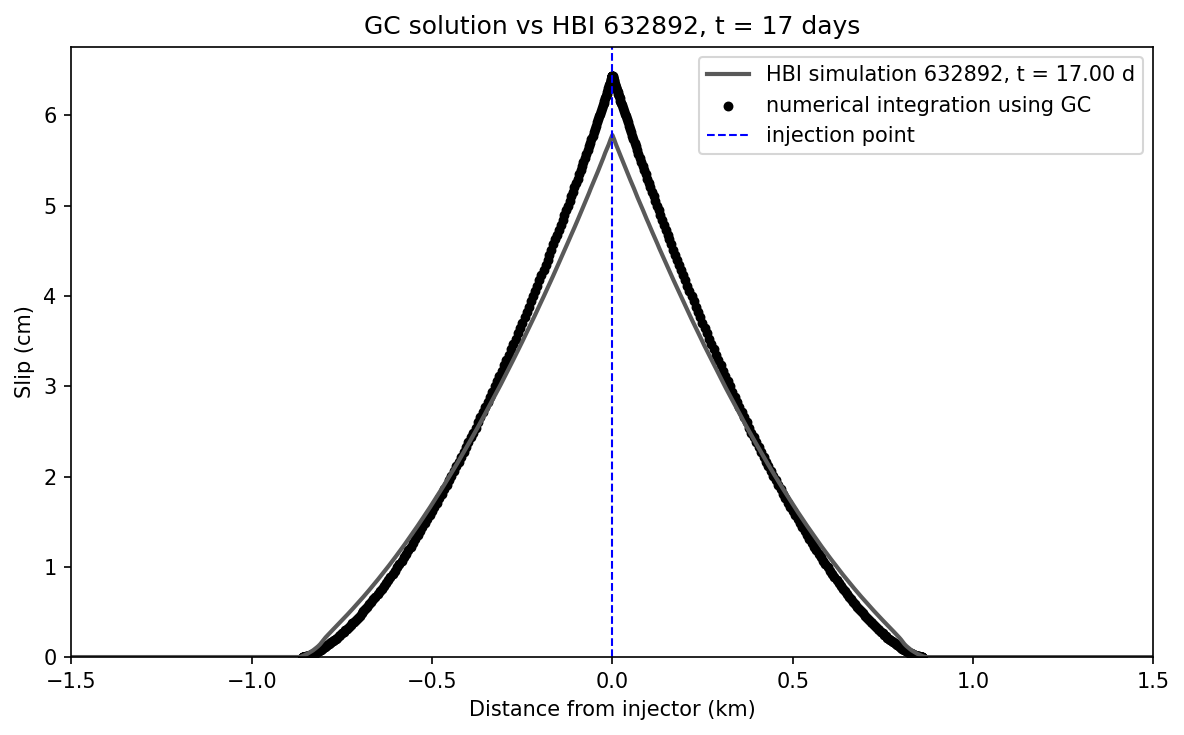


peak slip:  simulation 5.782 cm   GC 6.441 cm   ratio 0.8978


In [18]:
# ==============================================================
# Overlay the HBI simulation on the GC solution
# ==============================================================
# Run this AFTER the case = "point" cell, which must have defined
# r_full, slip_full, lam, R_t.
#
# 632892 is the run to compare against: 911's physics (kp = kpmin = 1e-15,
# kpmax 2.5e-13 => 250x enhancement range, permev T, ds 5 m) with a compliant
# wellbore (Sw_fwid 7.4e-7) so it is numerically feasible on the current code.
#
# alpha and deltaP below come from KPMAX, not kp. With enhancement the slipping
# region saturates at kpmax -- measured directly: the radius where k reaches
# 50% of kpmax tracks the slip front to within 5-10 m (one to two cells) at
# every time, so the medium really is uniform kpmax inside a growing disc.

import numpy as np
import matplotlib.pyplot as plt
from sim_curves import load_slip, sim_params, front_lambda

JOB = 632892
T_DAYS = 17

P = sim_params(JOB)
print("simulation parameters, read off the deck")
for k in ("f", "sigma_0", "tau_0", "mu", "alpha", "deltaP"):
    print(f"  {k:8s} = {P[k]:.6g}")
print(f"  permev {P['permev']}, k_eff = {P['k_eff']:.2e} (kpmax), ds = {P['ds_m']:.0f} m")

# These are what the cell above should be using. Small differences from the
# hardcoded 1.25 / 1.2e6 are harmless (0.1% and 0.9%).
print(f"\ncompare with the values set above: alpha 1.25 vs {P['alpha']:.4f}, "
      f"deltaP 1.2e6 vs {P['deltaP']:.4e}")

r_sim, slip_sim, t_actual = load_slip(JOB, T_DAYS)
print(f"\nloaded {JOB} at t = {t_actual:.4f} d (nearest snapshot to {T_DAYS})")

# lambda: threshold is explicit because it biases the result. The theory's edge
# is where slip -> 0, so a coarser threshold reports a smaller crack.
for thr in (1e-4, 1e-6, 1e-8):
    R, lam_sim, _ = front_lambda(JOB, T_DAYS, P["alpha"], thresh=thr)
    print(f"  thresh {thr:.0e} m -> R = {R:6.0f} m, lambda = {lam_sim:.4f}")
print(f"  analytical lambda from lambda_from_T = {lam:.4f}")
print(f"  analytical R_t = {R_t:.0f} m")

# mirror the simulation to a full diameter, as the GC curve already is
r_sim_full = np.concatenate([-r_sim[::-1], r_sim])
slip_sim_full = np.concatenate([slip_sim[::-1], slip_sim])

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(r_sim_full / 1000.0, slip_sim_full * 100.0, "-", color="0.35", lw=2.0,
         label=f"HBI simulation {JOB}, t = {t_actual:.2f} d")
plt.scatter(r_full / 1000.0, slip_full * 100.0, s=14, facecolors="k",
            label="numerical integration using GC")
plt.axvline(0, color="b", ls="--", lw=1, label="injection point")
plt.xlabel("Distance from injector (km)")
plt.ylabel("Slip (cm)")
plt.xlim(-1.5, 1.5)
plt.ylim(bottom=0)
plt.title(f"GC solution vs HBI {JOB}, t = {T_DAYS} days")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\npeak slip:  simulation {slip_sim[0]*100:.3f} cm   "
      f"GC {np.nanmax(slip_full)*100:.3f} cm   "
      f"ratio {slip_sim[0]/np.nanmax(slip_full):.4f}")


In [19]:
# from scipy.special import ellipk as K
# from scipy.special import ellipe as E
# from scipy.special import exp1
# from scipy.integrate import quad
# from scipy.optimize import newton

# # nonlinear solve using newton raphson method

# # parameters
# f_nl = 0.6
# sigma_0_nl = 30e6
# tau_0_nl = 11.1e6
# deltaP_nl = 1.2e6
# alpha_nl = 1.25
# mu_nl = 24e9
# epsilon_nl = 0

# # time
# some_time_days_nl = 17
# some_time_sec_nl = some_time_days_nl * 24 * 3600

# n_nl = 10000
# T_nl = (f_nl * sigma_0_nl - tau_0_nl) / (f_nl * deltaP_nl) # thi is the target T value we are trying to match
# print("T_nonlinear =", T_nl)


# # g definition
# def g_nl(xi, lam, epsilon):
#     term1 = exp1(lam**2 * xi**2)
#     term2 = exp1(lam**2)
#     term3 = (lam**(-2)) * np.exp(-lam**2)
#     return term1 - term2 + term3 - epsilon


# ### Propagation condition
# # T(lambda) = integral_0^1 g(xi, lambda, epsilon) xi/sqrt(1-xi^2) dxi
# # to integrate, use xi = sin(theta), so:
# # xi/sqrt(1-xi^2) dxi = xi dtheta

# def compute_T_nl(lam): # this calculation for T is done using the trig substitution which allows the integral to be evaluated analytically
#     def integrand(theta):
#         xi = np.sin(theta)
#         return float(g_nl(xi, lam, epsilon_nl) * xi)
#     result, error = quad(integrand, 0, 0.5 * np.pi, epsabs=1e-10, epsrel=1e-10, limit=200)
#     return result

# def propagation_residual_nl(lam):
#     return compute_T_nl(lam) - T_nl # goal is to get the residual to be as close as possible to 0

# def propagation_derivative_nl(lam): #using centered finite differences to approximate the derivative
#     h = max(1e-8, 1e-5 * abs(lam))
#     if lam - h > 0:
#         return (
#             propagation_residual_nl(lam + h) - propagation_residual_nl(lam - h)) / (2 * h)


# # initial guess for current parameters
# lam_guess_nl = 0.3
# lam_nl = newton(propagation_residual_nl, x0=lam_guess_nl, fprime=propagation_derivative_nl, tol=1e-12, maxiter=30)
# print("lambda nonlinear =", lam_nl)
# print("T(lambda nonlinear) =", compute_T_nl(lam_nl))
# print("propagation residual nonlinear =", propagation_residual_nl(lam_nl))


# # GC setup
# a_nl = np.arange(1, n_nl)
# b_nl = np.arange(1, n_nl + 1)
# r_i_nl = np.cos(np.pi * a_nl / n_nl)  # rtilde collocation points
# s_j_nl = np.cos(np.pi * (b_nl - 0.5) / n_nl) # stilde quadrature points
# r_i_bar_nl = 0.5 * (r_i_nl + 1) # rbar collocation points
# s_j_bar_nl = 0.5 * (s_j_nl + 1) # sbar quadrature points


# # putting together elastic kernel matrix
# u_nl = (r_i_nl[:, None] + 1) / (s_j_nl[None, :] + 1)
# k_u_nl = (2 * np.sqrt(u_nl)) / (1 + u_nl)
# m_nl = k_u_nl**2
# int1_nl = K(m_nl)
# int2_nl = E(m_nl)
# F_ij_nl = (int1_nl / (s_j_nl[None, :] + r_i_nl[:, None] + 2)+ int2_nl / (s_j_nl[None, :] - r_i_nl[:, None]))
# F_ij_nl = (-1 / n_nl) * F_ij_nl


# # RHS: gamma = g(rbar, lambda) - T
# gamma_i_nl = g_nl(r_i_bar_nl, lam_nl, epsilon_nl) - T_nl


# # asymptotic condition at the origin
# # Point-source case:
# # d(delta_tilde)/d(s_tilde) approaches -2 as s_tilde approaches -1+
# j0_nl = -1
# origin_row_nl = np.zeros((1, n_nl))
# origin_row_nl[0, j0_nl] = 1 / np.sqrt(1 - s_j_nl[j0_nl]**2)
# origin_rhs_nl = -2


# # linear solve for phi
# F_full_nl = np.vstack([F_ij_nl, origin_row_nl])
# rhs_full_nl = np.concatenate([gamma_i_nl, [origin_rhs_nl]])
# phi_nl = np.linalg.solve(F_full_nl, rhs_full_nl)
# print("origin derivative, nonlinear:",phi_nl[j0_nl] / np.sqrt(1 - s_j_nl[j0_nl]**2))


# # reconstruct slip from edge inwards
# deltabar_nl = np.zeros(n_nl)
# for k in range(n_nl):
#     x_k = s_j_nl[k]
#     delta_sum = 0
#     for j in range(n_nl):
#         H = np.heaviside(s_j_nl[j] - x_k, 0)
#         delta_sum += phi_nl[j] * H
#     deltabar_nl[k] = -(np.pi / n_nl) * delta_sum


# # dimensionalize slip distribution
# R_t_nl = lam_nl * np.sqrt(4 * alpha_nl * some_time_sec_nl)
# r_physical_nl = s_j_bar_nl * R_t_nl
# dim_factor_nl = R_t_nl * f_nl * deltaP_nl / mu_nl
# delta_plot_nl = dim_factor_nl * deltabar_nl
# r_full_nl = np.concatenate([-r_physical_nl[::-1], r_physical_nl])
# slip_full_nl = np.concatenate([delta_plot_nl[::-1], delta_plot_nl])

# print("R_t nonlinear (m):", R_t_nl)
# print("max slip nonlinear (cm):", np.nanmax(slip_full_nl) * 100)
# print("min slip nonlinear (cm):", np.nanmin(slip_full_nl) * 100)


# # nonlinear result plot
# plt.figure(figsize=(8, 5), dpi=150)
# plt.scatter(r_full_nl / 1000, slip_full_nl * 100, s=8, facecolors='k', label='nonlinear/Newton solve')
# plt.axvline(0, color='r',linestyle='--',linewidth=1,label='injection point')
# plt.xlabel('Distance from injector (km)')
# plt.ylabel('Slip (cm)')
# plt.title(f'nonlinear solve, t = {some_time_days_nl} days')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # saving nonlinear result
# lam_nonlinear = lam_nl
# phi_nonlinear = phi_nl.copy()
# r_full_nonlinear = r_full_nl.copy()
# slip_full_nonlinear = slip_full_nl.copy()
# R_t_nonlinear = R_t_nl

# print("saved nonlinear solution")
# print("lambda nonlinear:", lam_nonlinear)

In [20]:
# # ==================================================
# # Compare linear/helper solve and nonlinear/Newton solve
# # ==================================================

# # Sort both profiles by distance so interpolation works correctly
# idx_linear = np.argsort(r_full_linear)
# idx_nonlinear = np.argsort(r_full_nonlinear)

# x_linear_km = r_full_linear[idx_linear] / 1000.0
# slip_linear_cm = slip_full_linear[idx_linear] * 100.0

# x_nonlinear_km = r_full_nonlinear[idx_nonlinear] / 1000.0
# slip_nonlinear_cm = slip_full_nonlinear[idx_nonlinear] * 100.0

# # Common physical x-range
# x_min = max(np.nanmin(x_linear_km), np.nanmin(x_nonlinear_km))
# x_max = min(np.nanmax(x_linear_km), np.nanmax(x_nonlinear_km))

# x_common_km = np.linspace(x_min, x_max, 1000)

# # Interpolate both onto same x-grid
# slip_linear_common_cm = np.interp(x_common_km, x_linear_km, slip_linear_cm)
# slip_nonlinear_common_cm = np.interp(x_common_km, x_nonlinear_km, slip_nonlinear_cm)

# difference_cm = slip_nonlinear_common_cm - slip_linear_common_cm

# # Diagnostics
# print("lambda linear:", lam_linear)
# print("lambda nonlinear:", lam_nonlinear)
# print("relative lambda difference:", abs(lam_nonlinear - lam_linear) / abs(lam_linear))

# print("R_t linear (m):", R_t_linear)
# print("R_t nonlinear (m):", R_t_nonlinear)
# print("relative R_t difference:", abs(R_t_nonlinear - R_t_linear) / abs(R_t_linear))

# print("max slip linear (cm):", np.nanmax(slip_linear_cm))
# print("max slip nonlinear (cm):", np.nanmax(slip_nonlinear_cm))
# print("peak slip difference (cm):", np.nanmax(slip_nonlinear_cm) - np.nanmax(slip_linear_cm))

# print("max absolute pointwise difference (cm):", np.nanmax(np.abs(difference_cm)))
# print(
#     "relative L2 difference:",
#     np.linalg.norm(difference_cm) / np.linalg.norm(slip_linear_common_cm)
# )

# # Plot comparison
# fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=200)

# # Left: overlay profiles
# axes[0].scatter(
#     x_linear_km,
#     slip_linear_cm,
#     s=20,
#     facecolors='k',
#     label='linear lambda'
# )

# axes[0].scatter(
#     x_nonlinear_km,
#     slip_nonlinear_cm,
#     s=8,
#     facecolors='none',
#     edgecolors='r',
#     label='nonlinear lambda'
# )

# axes[0].axvline(0.0, color='b', linestyle='--', linewidth=1, label='injection')
# axes[0].set_xlabel('Distance from injector (km)')
# axes[0].set_ylabel('Slip (cm)')
# axes[0].set_title('slip profile comparison')
# axes[0].legend()

# # Right: difference
# axes[1].scatter(x_common_km, difference_cm,s=10,facecolors='k')

# axes[1].axvline(0.0, color='b', linestyle='--', linewidth=1)
# axes[1].set_xlabel('Distance from injector (km)')
# axes[1].set_ylabel('Nonlinear - linear slip (cm)')
# axes[1].set_title('difference')

# plt.tight_layout()
# plt.show()

In [ ]:
# ==============================================================
# GC analytical solution vs HBI simulation -- one figure per direction
# ==============================================================
# Run AFTER the case = "point" cell. Uses r_full, slip_full, lam, R_t from
# there, so editing deltaP/alpha/n up there moves these figures too.
#
# TWO FIGURES, NOT AN AVERAGE. The crack is not axisymmetric. From
# coordinate3ddip (main_LH.f90:1577) j is innermost and controls y,z, so
# reshape(IM,JM)[a,b] has a = STRIKE and b = DIP. Slip is along dip on a reverse
# fault, so along-dip growth is mode II and along-strike is mode III -- equal
# stiffness only at nu = 0. HBI runs at pois = 0.25 (m_const.f90:4, and
# res632892 does not override it) while the GC kernel has no nu in it and the
# Eshelby check above sets nu = 0. Hence 875 m along strike against 810 m along
# dip at 17 d: lambda 0.3229 vs 0.2989, with the analytical 0.3170 between them.
# pois IS settable from a deck (main_LH.f90:2697), so a rerun with pois 0 would
# collapse these two figures into one.

import numpy as np
import matplotlib.pyplot as plt
from sim_curves import load_slip

JOB    = 632892     # permev T, kp=kpmin=1e-15 -> kpmax=2.5e-13 (250x), ds 5 m
T_DAYS = 17
THRESH = 1e-4       # slip level defining the simulated crack edge

# Guard: the GC cell above has both a "constant" and a "point" branch, and the
# constant branch leaves slip_full as the ESHELBY solution at R_t = 50 m with
# lam = None. Plotting that against an 810 m crack is a silent, confusing
# failure, so fail loudly instead.
assert "case" not in dir() or case == "point", (
    f'set case = "point" in the GC cell; it is currently {case!r}, which leaves '
    f'slip_full as the Eshelby constant-stress-drop solution')
assert np.isscalar(lam) and lam is not None, (
    f"lam is {type(lam).__name__}; run the case = \"point\" cell, which sets it "
    f"to a scalar via lambda_from_T(). An earlier cell binds it to an ARRAY.")

pk_g = np.nanmax(slip_full) * 100
print(f"GC   lambda {lam:.4f}   R_t {R_t:.0f} m   peak {pk_g:.4f} cm\n")

NOTE = {"strike": "along-strike (mode III, perpendicular to slip)",
        "dip":    "along-dip (mode II, the slip direction)"}

for how in ("strike", "dip"):
    r_half, slip_half, t_act = load_slip(JOB, T_DAYS, how=how)
    r_sim    = np.concatenate([-r_half[::-1], r_half])
    slip_sim = np.concatenate([slip_half[::-1], slip_half])

    fig, ax = plt.subplots(figsize=(9.0, 5.2), dpi=150, constrained_layout=True)
    ax.plot(r_sim / 1000.0, slip_sim * 100.0, "-", color="#1a1a19", lw=2.2,
            label=f"HBI {JOB}, {how}, t = {t_act:.2f} d")
    ax.scatter(r_full / 1000.0, slip_full * 100.0, s=13, facecolors="#a8071a",
               edgecolors="none", zorder=3,
               label=rf"GC analytical, $\lambda$ = {lam:.4f}")
    ax.axvline(0, color="b", ls="--", lw=1, label="injection point")
    ax.set(xlabel=f"Distance along-{how} (km)", ylabel="Cumulative Slip (cm)",
           xlim=(-1.5, 1.5))
    ax.set_ylim(bottom=0)
    ax.set_title(f"GC analytical vs HBI {JOB}, {NOTE[how]}, t = {T_DAYS} d\n"
                 rf"$\lambda$ = {lam:.4f}, $R_t$ = {R_t:.0f} m, "
                 rf"$\alpha$ = {alpha}, $\Delta P$ = {deltaP/1e6:g} MPa",
                 fontsize=11)
    ax.legend(frameon=True, fontsize=9.5)
    plt.show()

    b = np.where(slip_half < THRESH)[0]
    R = r_half[b[0]] if len(b) else r_half[-1]
    lm = R / np.sqrt(4 * alpha * t_act * 86400)
    print(f"{NOTE[how]}")
    print(f"  peak slip  {slip_half[0]*100:.4f} cm     sim/GC "
          f"{slip_half[0]*100/pk_g:.4f}")
    print(f"  R {R:.0f} m (slip > {THRESH:.0e} m)   lambda {lm:.4f}   "
          f"lambda/GC {lm/lam:.4f}\n")
